# Imbalanced classification

## Project: oil spill classification

This is a modified version of the project in Jason Brownlee's e-book, _Imbalanced Classification with Python_.

In [1]:
from collections import Counter

from imblearn.combine import SMOTEENN
from imblearn.metrics import geometric_mean_score
from imblearn.pipeline import Pipeline as ImblearnPipeline
from imblearn.under_sampling import EditedNearestNeighbours
from matplotlib import pyplot
from numpy import mean, std
from pandas import read_csv
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, PowerTransformer, StandardScaler

### Load and explore the data

In [2]:
# define the dataset location
full_path = "data/oil-spill.csv"
# load the csv file as a data frame
dataframe = read_csv(full_path, header=None)
# summarize the shape of the dataset
print(dataframe.shape)
# summarize the class distribution
target = dataframe.values[:, -1]
counter = Counter(target)
for k, v in counter.items():
    per = v / len(target) * 100
    print("Class=%d, Count=%d, Percentage=%.3f%%" % (k, v, per))

(937, 50)
Class=1, Count=41, Percentage=4.376%
Class=0, Count=896, Percentage=95.624%


The 49 predictors are feature vectors extracted from image satellite pictures
of the ocean.

The image satellite pictures from which the feature vectors are extracted
are images of ocean areas in which an oil spill was suspected.

In this dataset, we have significant class imbalance.

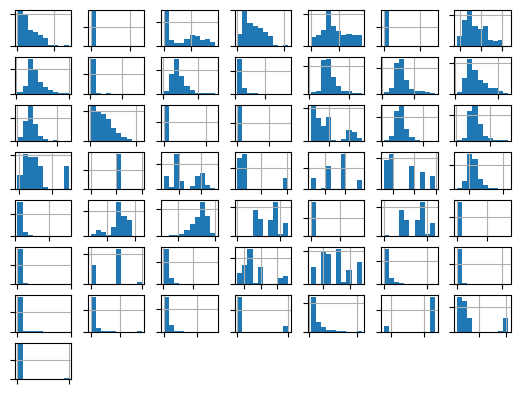

In [3]:
# create a histogram plot of each variable
ax = dataframe.hist()
# disable axis labels
for axis in ax.flatten():
    axis.set_title("")
    axis.set_xticklabels([])
    axis.set_yticklabels([])
pyplot.show()

### Create a baseline model

Some utility functions.

Note that we use stratified cross-validation to ensure that the distribution
of class labels in each fold is the same as the distribution of the class
labels in the full dataset.

In [9]:
# load the dataset
def load_dataset(full_path):
    # load the dataset as a numpy array
    data = read_csv(full_path, header=None)
    # drop unused columns
    data.drop(22, axis=1, inplace=True)
    data.drop(0, axis=1, inplace=True)
    # retrieve numpy array
    data = data.values
    # split into input and output elements
    X, y = data[:, :-1], data[:, -1]
    # label encode the target variable to have the classes 0 and 1
    y = LabelEncoder().fit_transform(y)
    return X, y


# evaluate a model
def evaluate_model(X, y, model):
    # define evaluation procedure
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    # define the model evaluation the metric
    metric = make_scorer(geometric_mean_score)
    # evaluate model
    scores = cross_val_score(model, X, y, scoring=metric, cv=cv, n_jobs=-1)
    return scores

In [10]:
# load the dataset
X, y = load_dataset(full_path)
# summarize the loaded dataset
print(X.shape, y.shape, Counter(y))
# define the reference model
model = DummyClassifier(strategy="uniform", random_state=1)
# evaluate the model
scores = evaluate_model(X, y, model)
baseline_performance = mean(scores)
# summarize performance
print("Mean G-Mean: %.3f (%.3f)" % (mean(scores), std(scores)))

(937, 47) (937,) Counter({0: 896, 1: 41})
Mean G-Mean: 0.541 (0.106)


Note that we are using a `DummyClassifier` that generates class predictions
uniformly at random between the 2 classes.

This is a better baseline than the majority class classifier, because that
classifier would have a G-mean of 0.

### Try out some models

Utility function.

In [11]:
# define models to test
def get_models():
    models, names = list(), list()
    # LR
    steps = [
        ("t", StandardScaler()),
        ("m", LogisticRegression(solver="liblinear", random_state=1)),
    ]
    models.append(Pipeline(steps=steps))
    names.append("LR-Std")
    # LDA
    models.append(LinearDiscriminantAnalysis())
    names.append("LDA")
    # NB
    models.append(GaussianNB())
    names.append("GNB")
    return models, names

Note that the models do not require tuning, so the cross-validation error
is a honest estimate of the generalization error of these models
(in this case measured in terms of the G-mean score).

>LR-Std 0.672 (0.203)
>LDA 0.755 (0.147)
>GNB 0.707 (0.202)


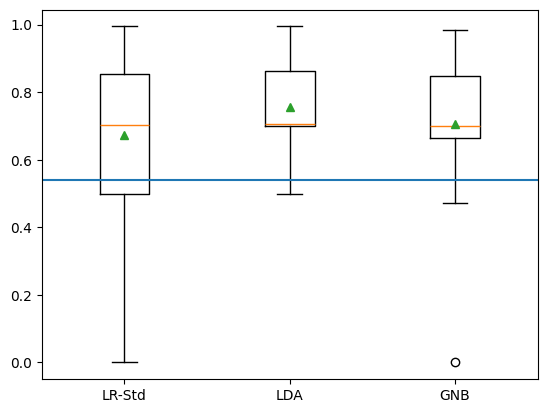

In [12]:
# define models
models, names = get_models()
# evaluate each model
results = list()
for i in range(len(models)):
    # evaluate the model and store results
    scores = evaluate_model(X, y, models[i])
    results.append(scores)
    # summarize and store
    print(">%s %.3f (%.3f)" % (names[i], mean(scores), std(scores)))
# plot the results
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.axhline(baseline_performance)
pyplot.show()

On average, these models all appear "skillful" compared to the baseline
classifier.

### Try weighted logistic regression

We saw that the distribution of some of the predictors is very far from
Gaussian.

This is possibly affecting negatively some of these models (recall
e.g., the assumptions of LDA, QDA, Gaussian Naive Bayes).

Let's see if we can improve these models by applying a power transform.

Note that `PowerTransformer` uses the Yeo-Johnson transform by default,
which is essentially a generalization of the Box-Cox transform.

Also, let's see if using a weighted version of the logistic regression model
generates an improvement.

In [13]:
# define models to test
def get_models():
    models, names = list(), list()
    # LR Balanced + Standardization
    steps = [
        ("t", StandardScaler()),
        (
            "m",
            LogisticRegression(
                solver="liblinear", class_weight="balanced", random_state=1
            ),
        ),
    ]
    models.append(Pipeline(steps=steps))
    names.append("LR-W-Std")
    # LR Balanced + Power + Standardization
    steps = [
        ("t1", StandardScaler()),
        ("t2", PowerTransformer()),
        (
            "m",
            LogisticRegression(
                solver="liblinear", class_weight="balanced", random_state=1
            ),
        ),
    ]
    models.append(Pipeline(steps=steps))
    names.append("LR-W-Std-Power")
    # LDA + Power
    steps = [("t", PowerTransformer()), ("m", LinearDiscriminantAnalysis())]
    models.append(Pipeline(steps=steps))
    names.append("LDA-Power")
    # NB + Power
    steps = [("t", PowerTransformer()), ("m", GaussianNB())]
    models.append(Pipeline(steps=steps))
    names.append("GNB-Power")
    return models, names

>LR-W-Std 0.834 (0.129)
>LR-W-Std-Power 0.840 (0.127)
>LDA-Power 0.560 (0.283)
>GNB-Power 0.601 (0.068)


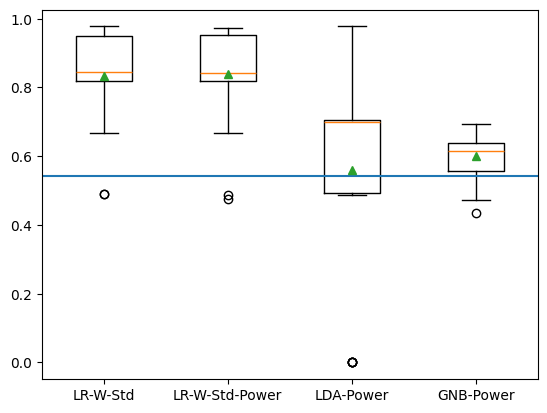

In [14]:
# define models
models, names = get_models()
# evaluate each model
results = list()
for i in range(len(models)):
    # evaluate the model and store results
    scores = evaluate_model(X, y, models[i])
    results.append(scores)
    # summarize and store
    print(">%s %.3f (%.3f)" % (names[i], mean(scores), std(scores)))
# plot the results
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.axhline(baseline_performance)
pyplot.show()

The logistic regression model has greatly improved thanks to the weighthing.

### Try over/undersampling

Let's see if we can improve this further by means of over/undersampling.

In [15]:
# define models to test
def get_models():
    models, names = list(), list()
    # LR + SMOTEENN + Standardization
    sampling = SMOTEENN(
        enn=EditedNearestNeighbours(sampling_strategy="majority"), random_state=1
    )
    model = LogisticRegression(solver="liblinear", random_state=1)
    steps = [("t", StandardScaler()), ("e", sampling), ("m", model)]
    models.append(ImblearnPipeline(steps=steps))
    names.append("LR-Std-Smt")
    # LR SMOTEENN + Power + Standardization
    sampling = SMOTEENN(
        enn=EditedNearestNeighbours(sampling_strategy="majority"), random_state=1
    )
    model = LogisticRegression(solver="liblinear", random_state=1)
    steps = [
        ("t1", StandardScaler()),
        ("t2", PowerTransformer()),
        ("e", sampling),
        ("m", model),
    ]
    models.append(ImblearnPipeline(steps=steps))
    names.append("LR-Std-Power-Smt")
    # LR Balanced + SMOTEENN + Power + Standardization
    sampling = SMOTEENN(
        enn=EditedNearestNeighbours(sampling_strategy="majority"), random_state=1
    )
    model = LogisticRegression(
        solver="liblinear", class_weight="balanced", random_state=1
    )
    steps = [
        ("t1", StandardScaler()),
        ("t2", PowerTransformer()),
        ("e", sampling),
        ("m", model),
    ]
    models.append(ImblearnPipeline(steps=steps))
    names.append("LR-W-Std-Power-Smt")
    return models, names

Note that the last model uses `SMOTEEEN` _and_ also uses weights in the
logistic regression model.

>LR-Std-Smt 0.830 (0.123)
>LR-Std-Power-Smt 0.859 (0.112)
>LR-W-Std-Power-Smt 0.860 (0.112)


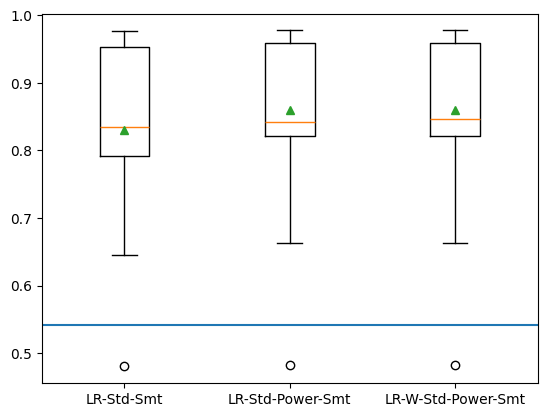

In [16]:
# define models
models, names = get_models()
# evaluate each model
results = list()
for i in range(len(models)):
    # evaluate the model and store results
    scores = evaluate_model(X, y, models[i])
    # summarize and store
    print(">%s %.3f (%.3f)" % (names[i], mean(scores), std(scores)))
    results.append(scores)
# plot the results
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.axhline(baseline_performance)
pyplot.show()

Perhaps we see a small additional improvement thanks to SMOTEEN.

### Exercises left to the reader

#### Exercise 1
Could we make `SMOTEENN` more effective by e.g., tuning the number of neighbors
used in `ENN`?

#### Exercise 2
Try substituting `SMOTETomek` for `SMOTEENN`.